In [48]:
import datetime
import pandas
from matplotlib import pyplot
from matplotlib import dates
import time
import re
import json
from dateutil import parser

### Задание 1.

In [49]:
class Account:
    _account_counter = 1000

    def __init__(self, account_holder: str, balance: float = 0):
        if balance < 0:
            raise ValueError("Начальный баланс не может быть отрицательным.")

        self.holder = account_holder
        self.account_number = f'ACC-{Account._account_counter}'
        Account._account_counter += 1

        self._balance = balance
        self.operations_history = []

        self._add_operation(
            operation_type='open',
            amount=balance,
            status='success'
        )

    @property
    def balance(self):
        return self._balance

    def deposit(self, amount: float):
        if amount <= 0:
            raise ValueError("Сумма пополнения должна быть положительной.")

        self._balance += amount
        self._add_operation(
            operation_type='deposit',
            amount=amount,
            status='success'
        )
        return True

    def withdraw(self, amount: float):
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной.")

        if amount <= self._balance:
            self._balance -= amount
            self._add_operation(
                operation_type='withdraw',
                amount=amount,
                status='success'
            )
            return True
        else:
            self._add_operation(
                operation_type='withdraw',
                amount=amount,
                status='fail'
            )
            return False

    def get_balance(self):
        return self._balance

    def get_history(self):
        return self.operations_history.copy()

    def _add_operation(self, operation_type: str, amount: float, status: str):
        operation = {
            'type': operation_type,
            'amount': amount,
            'datetime': datetime.datetime.now(),
            'balance_after': self._balance,
            'status': status
        }
        self.operations_history.append(operation)

    def __str__(self):
        return f"Счет {self.account_number} ({self.holder}): баланс {self._balance:.2f}"

    def _get_valid_operations(self):
        return ['deposit', 'withdraw']

    def load_history_from_file(self, filepath: str, file_format: str = 'csv'):
        if file_format == 'csv':
            df = pandas.read_csv(filepath)
        elif file_format == 'json':
            df = pandas.read_json(filepath)
        else:
            raise ValueError("Неподдерживаемый формат файла. Используйте 'csv' или 'json'")

        account_transactions = df[df['account_number'] == self.account_number].copy()

        if account_transactions.empty:
            print(f"Транзакции для счета {self.account_number} не найдены")
            return

        cleaned_transactions = self.clean_history(account_transactions)

        initial_operation = self.operations_history[0] if self.operations_history else None
        self.operations_history = []
        if initial_operation:
            self.operations_history.append(initial_operation)
            self._balance = initial_operation['balance_after']
        else:
            self._balance = 0

        for _, transaction in cleaned_transactions.iterrows():
            operation = {
                'type': transaction['operation'],
                'amount': transaction['amount'],
                'datetime': transaction['date'],
                'balance_after': transaction['balance_after'],
                'status': transaction['status']
            }
            self.operations_history.append(operation)

        if self.operations_history:
            self._balance = self.operations_history[-1]['balance_after']

        print(f"Загружено {len(cleaned_transactions)} транзакций для счета {self.account_number}")
        print(f"Текущий баланс: {self._balance:.2f}")

    def clean_history(self, transactions_df):
        cleaned_df = transactions_df.copy()
        valid_operations = self._get_valid_operations()

        indices_to_drop = []

        for idx, row in cleaned_df.iterrows():
            operation = row['operation']

            if pandas.isna(operation) or operation == '' or operation not in valid_operations:
                print(f"Строка {idx}: пропущена - неизвестная операция '{operation}'")
                indices_to_drop.append(idx)
                continue

            amount = row['amount']

            if pandas.isna(amount) or amount == '' or amount < 0:
                print(f"Строка {idx}: пропущена - невалидная сумма")
                indices_to_drop.append(idx)
                continue

            date_str = row['date']

            if pandas.isna(date_str) or date_str == '':
                print(f"Строка {idx}: пропущена - отсутствует дата")
                indices_to_drop.append(idx)
                continue

            try:
                parsed_date = parser.parse(str(date_str), dayfirst=True)
                cleaned_df.at[idx, 'date'] = parsed_date
            except (ValueError, parser.ParserError):
                print(f"Строка {idx}: пропущена - невалидная дата '{date_str}'")
                indices_to_drop.append(idx)
                continue

        cleaned_df = cleaned_df.drop(indices_to_drop)

        before_dedup = len(cleaned_df)
        cleaned_df = cleaned_df.drop_duplicates(subset=['account_number', 'date', 'operation', 'amount', 'balance_after'])
        duplicates_removed = before_dedup - len(cleaned_df)

        cleaned_df = cleaned_df.sort_values('date').reset_index(drop=True)

        print(f"\nИтого: невалидных записей удалено - {len(indices_to_drop)}, дубликатов удалено - {duplicates_removed}")

        return cleaned_df

    def plot_history(self):
        if not self.operations_history:
            print("История операций пуста")
            return

        df = pandas.DataFrame(self.operations_history)

        print("\nИстория операций в виде DataFrame:")
        print(df.to_string(index=False))

        pyplot.figure(figsize=(12, 6))

        pyplot.plot(df['datetime'], df['balance_after'],
                marker='o', linestyle='-', linewidth=2,
                markersize=8, color='blue', label='Баланс')

        failed_ops = df[df['status'] == 'fail']
        if not failed_ops.empty:
            pyplot.scatter(failed_ops['datetime'], failed_ops['balance_after'],
                       color='red', s=100, marker='x',
                       linewidths=3, label='Неудачная операция', zorder=5)

        pyplot.title(f'История изменения баланса\nСчет: {self.account_number} ({self.holder})',
                 fontsize=14, fontweight='bold')
        pyplot.xlabel('Дата и время операции', fontsize=12)
        pyplot.ylabel('Баланс (руб.)', fontsize=12)
        pyplot.grid(True, alpha=0.3, linestyle='--')
        ax = pyplot.gca()

        ax.xaxis.set_major_formatter(dates.DateFormatter('%H:%M:%S'))

        pyplot.xticks(rotation=45, ha='right')

        ax.yaxis.set_major_formatter(pyplot.FuncFormatter(lambda x, p: f'{x:,.0f}'))

        pyplot.tight_layout()
        pyplot.show()
        return df

### Тут немного потестил

Счет ACC-1000 (Фродо Бэггинс): баланс 5000.00

Текущий баланс: 4000.00 руб.

История операций в виде DataFrame:
    type  amount                   datetime  balance_after  status
    open    5000 2025-11-09 16:06:16.554725           5000 success
 deposit    1500 2025-11-09 16:06:16.554793           6500 success
withdraw     800 2025-11-09 16:06:16.960164           5700 success
 deposit    2000 2025-11-09 16:06:18.660564           7700 success
withdraw    3000 2025-11-09 16:06:18.861138           4700 success
withdraw   10000 2025-11-09 16:06:18.966310           4700    fail
 deposit     500 2025-11-09 16:06:19.271456           5200 success
withdraw    1200 2025-11-09 16:06:20.276901           4000 success


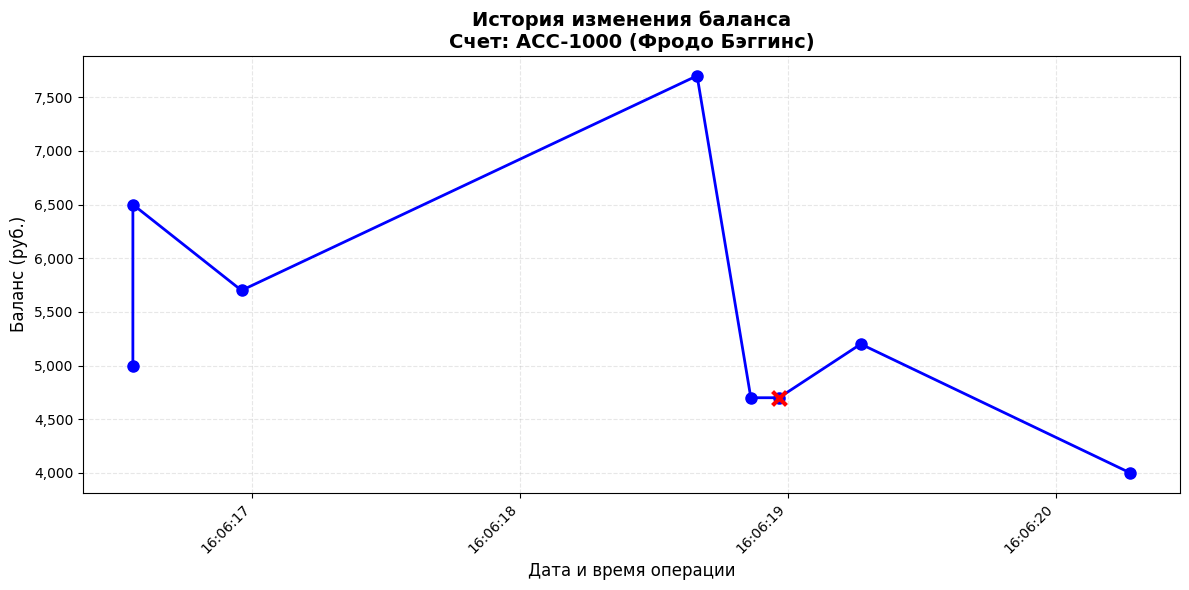

In [50]:
account = Account("Фродо Бэггинс", 5000)
print(account)

account.deposit(1500)
time.sleep(0.4)

account.withdraw(800)
time.sleep(1.7)

account.deposit(2000)
time.sleep(0.2)

account.withdraw(3000)
time.sleep(0.1)

account.withdraw(10000)
time.sleep(0.3)

account.deposit(500)
time.sleep(1)

account.withdraw(1200)

print(f"\nТекущий баланс: {account.get_balance():.2f} руб.")

df = account.plot_history()

### Задание 2.

In [51]:
class CheckingAccount(Account):
    account_type = 'Checking'

    def __init__(self, account_holder: str, balance: float = 0):
        self._validate_holder_name(account_holder)
        super().__init__(account_holder, balance)

    @staticmethod
    def _validate_holder_name(name: str):

        pattern = r'^[A-ZА-ЯЁ][a-zа-яе]+ [A-ZА-ЯЁ][a-zа-яе]+$'
        if not re.match(pattern, name):
            raise ValueError(
                "Имя владельца должно быть в формате 'Имя Фамилия' "
                "с заглавных букв (кириллица или латиница)"
            )
    def __str__(self):
        return f"Расчетный счет {self.account_number} ({self.holder}): баланс {self._balance:.2f}"

In [52]:
class SavingsAccount(Account):
    account_type = 'Savings'

    def __init__(self, account_holder: str, balance: float = 0):
        self._validate_holder_name(account_holder)
        super().__init__(account_holder, balance)

    @staticmethod
    def _validate_holder_name(name: str):
        pattern = r'^[A-ZА-ЯЁ][a-zа-яе]+ [A-ZА-ЯЁ][a-zа-яе]+$'

        if not re.match(pattern, name):
            raise ValueError(
                "Имя владельца должно быть в формате 'Имя Фамилия' "
                "с заглавных букв (кириллица или латиница)"
            )

    def withdraw(self, amount: float):
        if amount <= 0:
            raise ValueError("Сумма снятия должна быть положительной.")

        max_withdrawal = self._balance * 0.5

        if amount > max_withdrawal:
            self._add_operation(
                operation_type='withdraw',
                amount=amount,
                status='fail'
            )
            print(f"Ошибка: нельзя снять больше 50% от баланса. "
                  f"Максимальная сумма снятия: {max_withdrawal:.2f}")
            return False

        if amount <= self._balance:
            self._balance -= amount
            self._add_operation(
                operation_type='withdraw',
                amount=amount,
                status='success'
            )
            return True
        else:
            self._add_operation(
                operation_type='withdraw',
                amount=amount,
                status='fail'
            )
            return False

    def apply_interest(self, rate: float):
        if rate < 0:
            raise ValueError("Процентная ставка не может быть отрицательной.")

        interest = self._balance * (rate / 100)
        self._balance += interest

        self._add_operation(
            operation_type='interest',
            amount=interest,
            status='success'
        )

        print(f"Начислены проценты: {interest:.2f} руб. (ставка {rate}%)")
        return interest

    def __str__(self):
        return f"Сберегательный счет {self.account_number} ({self.holder}): баланс {self._balance:.2f}"

    def get_largest_operations(self, n: int = 5):
        if not self.operations_history:
            print("История операций пуста")
            return None

        df = pandas.DataFrame(self.operations_history)

        largest = df.nlargest(n, 'amount')

        print(f"\nТоп-{n} крупнейших операций:")
        print(largest[['datetime', 'type', 'amount', 'status', 'balance_after']].to_string(index=False))

        return largest

    def _get_valid_operations(self):
        return ['deposit', 'withdraw', 'interest']

### Мини тестирование

In [53]:
acc1 = CheckingAccount("Сэм Гэмджи", 10000)
print(f"Создан: {acc1}")

acc2 = SavingsAccount("Мерри Брендизайк", 5000)
print(f"Создан: {acc2}")

try:
    acc3 = CheckingAccount("сэм гэмджи", 1000)
except ValueError as e:
    print(f"Ошибка валидации: {e}")

try:
    acc4 = CheckingAccount("Сэм", 1000)
except ValueError as e:
    print(f"Ошибка валидации: {e}")

try:
    acc5 = CheckingAccount("Сэмn123 Гэмджи", 1000)
except ValueError as e:
    print(f"Ошибка валидации: {e}")


checking = CheckingAccount("Гэндальф Серый", 10000)
checking.deposit(5000)
checking.withdraw(3000)
checking.withdraw(8000)
print(f"Баланс: {checking.get_balance():.2f}")

Создан: Расчетный счет ACC-1001 (Сэм Гэмджи): баланс 10000.00
Создан: Сберегательный счет ACC-1002 (Мерри Брендизайк): баланс 5000.00
Ошибка валидации: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв (кириллица или латиница)
Ошибка валидации: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв (кириллица или латиница)
Ошибка валидации: Имя владельца должно быть в формате 'Имя Фамилия' с заглавных букв (кириллица или латиница)
Баланс: 4000.00


In [54]:
savings = SavingsAccount("Арагорн Бродяжник", 10000)
print(f"Начальный баланс: {savings.get_balance():.2f}")

print("\nПопытка снять 60% от баланса:")
savings.withdraw(6000)

print("\nПопытка снять 40% от баланса:")
savings.withdraw(4000)
print(f"Баланс после снятия: {savings.get_balance():.2f}")

print("\nНачисление процентов 7%:")
savings.apply_interest(7)
print(f"Баланс после процентов: {savings.get_balance():.2f}")

savings.deposit(2000)
savings.deposit(1500)
savings.withdraw(500)

savings.get_largest_operations(5)

try:
    checking.deposit(-100)
except ValueError as e:
    print(f"Отрицательное пополнение: {e}")

try:
    savings.apply_interest(-5)
except ValueError as e:
    print(f"Отрицательная ставка: {e}")

Начальный баланс: 10000.00

Попытка снять 60% от баланса:
Ошибка: нельзя снять больше 50% от баланса. Максимальная сумма снятия: 5000.00

Попытка снять 40% от баланса:
Баланс после снятия: 6000.00

Начисление процентов 7%:
Начислены проценты: 420.00 руб. (ставка 7%)
Баланс после процентов: 6420.00

Топ-5 крупнейших операций:
                  datetime     type  amount  status  balance_after
2025-11-09 16:06:20.403910     open 10000.0 success        10000.0
2025-11-09 16:06:20.404075 withdraw  6000.0    fail        10000.0
2025-11-09 16:06:20.404105 withdraw  4000.0 success         6000.0
2025-11-09 16:06:20.404182  deposit  2000.0 success         8420.0
2025-11-09 16:06:20.404192  deposit  1500.0 success         9920.0
Отрицательное пополнение: Сумма пополнения должна быть положительной.
Отрицательная ставка: Процентная ставка не может быть отрицательной.


### Задание 3. Добавил выше

In [55]:
print("Загрузка данных из CSV файла")

checking = CheckingAccount("Фродо Бэггинс", balance=1200)
checking.account_number = "ACC-100001"
print(f"Начальный баланс: {checking.balance:.2f}")

checking.load_history_from_file('transactions_dirty.csv', file_format='csv')
print(f"Баланс после загрузки: {checking.balance:.2f}")


history = checking.get_history()
for i, op in enumerate(history, 1):
    print(f"   {i}. {op['datetime']}: {op['type']} - {op['amount']:.2f}, "
            f"баланс: {op['balance_after']:.2f}, статус: {op['status']}")



Загрузка данных из CSV файла
Начальный баланс: 1200.00
Строка 5: пропущена - невалидная сумма
Строка 8: пропущена - неизвестная операция 'nan'
Строка 10: пропущена - неизвестная операция 'interest'
Строка 13: пропущена - невалидная дата '2025-17-34 12:00:00'
Строка 15: пропущена - неизвестная операция 'diposit'
Строка 16: пропущена - неизвестная операция 'interest'
Строка 17: пропущена - невалидная дата '2023-16-40 12:00:00'

Итого: невалидных записей удалено - 7, дубликатов удалено - 1
Загружено 18 транзакций для счета ACC-100001
Текущий баланс: 7292.00
Баланс после загрузки: 7292.00
   1. 2025-11-09 16:06:20.411443: open - 1200.00, баланс: 1200.00, статус: success
   2. 2025-01-10 22:17:26: withdraw - 245.00, баланс: 4031.00, статус: success
   3. 2025-01-10 22:17:26: withdraw - 65.00, баланс: 3622.00, статус: success
   4. 2025-01-10 22:17:26: withdraw - 352.00, баланс: 3687.00, статус: success
   5. 2025-05-10 22:17:26: deposit - 327.00, баланс: 4890.00, статус: success
   6. 2025-

In [56]:
print("Загрузка данных из JSON файла")

savings = SavingsAccount("Арагорн Бродяжник", balance=1500)
savings.account_number = "ACC-100002"
print(f"Начальный баланс: {savings.balance:.2f}")

savings.load_history_from_file('transactions_dirty.json', file_format='json')
print(f"Баланс после загрузки: {savings.balance:.2f}")

history = savings.get_history()
for i, op in enumerate(history, 1):
    print(f"   {i}. {op['datetime']}: {op['type']} - {op['amount']:.2f}, "
            f"баланс: {op['balance_after']:.2f}, статус: {op['status']}")


Загрузка данных из JSON файла
Начальный баланс: 1500.00
Строка 28: пропущена - невалидная дата '2023-22-32 12:00:00'
Строка 29: пропущена - невалидная сумма
Строка 33: пропущена - невалидная сумма
Строка 37: пропущена - неизвестная операция 'diposit'
Строка 44: пропущена - невалидная сумма
Строка 48: пропущена - неизвестная операция 'wdraw'

Итого: невалидных записей удалено - 6, дубликатов удалено - 2
Загружено 19 транзакций для счета ACC-100002
Текущий баланс: 6153.53
Баланс после загрузки: 6153.53
   1. 2025-11-09 16:08:26.755372: open - 1500.00, баланс: 1500.00, статус: success
   2. 2025-02-10 22:17:26: deposit - 840.00, баланс: 3665.55, статус: success
   3. 2025-06-10 22:17:26: interest - 192.44, баланс: 4041.27, статус: success
   4. 2025-08-10 22:17:26: deposit - 426.00, баланс: 4603.27, статус: success
   5. 2025-09-10 22:17:26: deposit - 622.00, баланс: 6125.27, статус: success
   6. 2025-09-10 22:17:26: withdraw - 170.00, баланс: 5071.27, статус: success
   7. 2025-09-27 22